
# Pronóstico climático mensual 2025–2027

Este notebook toma como base `clima_mes_2005-2025.csv` y genera:

- entrenamiento de modelos por **municipio-variable**
- comparación entre modelos
- selección automática del mejor modelo
- pronóstico mensual hasta 2027
- archivo final `clima_mes_2005-2027.csv`

La lógica del notebook es pronosticar variables climáticas mensuales base y no las features derivadas del índice.


### 1. Lectura de archivos

In [15]:
# Librerías
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [16]:
# Directorios (Inputs / Outputs)
PROJECT_ROOT = Path().resolve().parents[1]

PATH_PROCESSED = PROJECT_ROOT / "data" / "processed"
PATH_MODEL = PROJECT_ROOT / "data" / "model"
PATH_OUTPUTS = PROJECT_ROOT / "data" / "outputs"

INPUT_FILE = PATH_PROCESSED / "clima_mes_2005-2025.csv"

OUTPUT_CLIMA = PATH_PROCESSED / "clima_mes_2005-2027.csv"
OUTPUT_PRONOSTICO = PATH_OUTPUTS / "clima_mes_pronostico_2025-2027.csv"
OUTPUT_METRICAS = PATH_MODEL / "metricas_pronostico_climatico.csv"
OUTPUT_MODELOS = PATH_MODEL / "modelos_seleccionados_pronostico.csv"

In [17]:
# Carga de datos climáticos mensuales entre 2005 y 2025
df = pd.read_csv(INPUT_FILE)

df["date"] = pd.to_datetime(
    df["anio"].astype(str) + "-" + df["mes"].astype(str) + "-01"
)

df = df.sort_values(["municipio", "date"]).reset_index(drop=True)
df.head()

,municipio,date,anio,mes,precip_mm,precip_mean_mm,precip_max_mm,ndvi_mean,ndvi_min,ndvi_max,...,flag_precip_baja_p10,flag_precip_alta_p90,flag_deficit_alto_p90,flag_exceso_alto_p90,flag_temp_media_alta_p90,flag_temp_media_baja_p10,flag_temp_max_alta_p90,flag_temp_min_baja_p10,flag_ndvi_bajo_p10,flag_ndvi_alto_p90
0,Aguadas,2005-01-01,2005,1,114.152754,3.682347,30.293657,0.679196,0.0297,0.9985,...,0,0,0,0,0,0,0,0,1,0
1,Aguadas,2005-02-01,2005,2,92.367963,3.298856,34.730915,0.694763,0.0376,0.9993,...,0,0,0,0,0,0,0,0,0,0
2,Aguadas,2005-03-01,2005,3,212.648689,6.859635,30.772394,0.735368,0.0487,0.9991,...,0,0,0,0,0,0,0,0,0,1
3,Aguadas,2005-04-01,2005,4,222.890335,7.429678,19.728767,0.683401,0.0158,0.9988,...,0,0,1,0,0,0,0,0,0,0
4,Aguadas,2005-05-01,2005,5,365.459124,11.789004,38.967903,0.756183,0.0261,0.9982,...,0,0,1,0,0,0,0,1,0,0


In [18]:
# Selección de variables a pronosticar
variables_clima = [
    "precip_mm",
    "temp_mean",
    "et_real_mm",
    "ndvi_mean"
]

variables_clima = [v for v in variables_clima if v in df.columns]
variables_clima

['precip_mm', 'temp_mean', 'et_real_mm', 'ndvi_mean']

### 2. Funciones auxiliares

In [19]:
# Función para pronóstico climático (estacional)
def forecast_seasonal(train, fechas):
    df_aux = train.to_frame("y")
    df_aux["mes"] = df_aux.index.month
    
    clim = df_aux.groupby("mes")["y"].mean()
    
    return pd.Series(
        [clim.get(f.month, train.mean()) for f in fechas],
        index=fechas
    )

# Función para pronóstico climático (Random Forest + Rezagos)
def forecast_rf(train, fechas):
    
    df_lag = pd.DataFrame({"y": train})
    
    for lag in [1, 2, 3, 12]:
        df_lag[f"lag_{lag}"] = df_lag["y"].shift(lag)
    
    df_lag = df_lag.dropna()
    
    X = df_lag.drop(columns=["y"])
    y = df_lag["y"]
    
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=6,
        random_state=42
    )
    
    model.fit(X, y)
    
    historial = train.copy()
    preds = []
    
    for f in fechas:
        row = {f"lag_{l}": historial.iloc[-l] for l in [1,2,3,12]}
        pred = model.predict(pd.DataFrame([row]))[0]
        
        preds.append(pred)
        historial.loc[f] = pred
    
    return pd.Series(preds, index=fechas)

In [20]:
# Fechas de pronóstico
fecha_inicio = df["date"].max() + pd.offsets.MonthBegin(1)
fecha_fin = pd.to_datetime("2027-12-01")

fechas_futuras = pd.date_range(fecha_inicio, fecha_fin, freq="MS")

### 3. Entrenamiento y selección

In [21]:
metricas = []
pronosticos = []

for municipio in df["municipio"].unique():
    
    df_m = df[df["municipio"] == municipio]
    
    for var in variables_clima:
        
        serie = df_m.set_index("date")[var].dropna()
        
        if len(serie) < 36:
            continue
        
        # split simple
        split = int(len(serie) * 0.9)
        train = serie.iloc[:split]
        test = serie.iloc[split:]
        
        fechas_test = test.index
        
        # modelos
        pred_seasonal = forecast_seasonal(train, fechas_test)
        pred_rf = forecast_rf(train, fechas_test)
        
        mae_seasonal = mean_absolute_error(test, pred_seasonal)
        mae_rf = mean_absolute_error(test, pred_rf)
        
        mejor = "rf" if mae_rf < mae_seasonal else "seasonal"
        
        metricas.append({
            "municipio": municipio,
            "variable": var,
            "mae_seasonal": mae_seasonal,
            "mae_rf": mae_rf,
            "modelo_seleccionado": mejor
        })
        
        # forecast final
        if mejor == "rf":
            pred_fut = forecast_rf(serie, fechas_futuras)
        else:
            pred_fut = forecast_seasonal(serie, fechas_futuras)
        
        tmp = pd.DataFrame({
            "municipio": municipio,
            "date": fechas_futuras,
            "variable": var,
            "valor": pred_fut.values
        })
        
        pronosticos.append(tmp)

In [22]:
metricas_df = pd.DataFrame(metricas)
pronosticos_df = pd.concat(pronosticos)

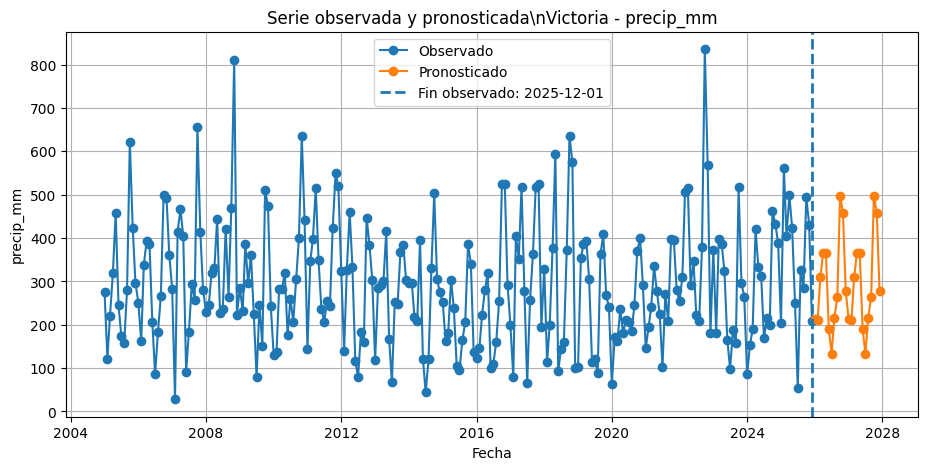

In [ ]:
# Gráfica separando observado y pronosticado
municipio_ejemplo = df_final["municipio"].dropna().sample(1, random_state=42).iloc[0]
variable_ejemplo = variables_clima[0]

df_plot = df_final[
    df_final["municipio"] == municipio_ejemplo
].copy()

df_obs_plot = df_plot[df_plot["tipo_dato"] == "observado"]
df_pred_plot = df_plot[df_plot["tipo_dato"] == "pronosticado"]

fecha_corte = df["date"].max()

plt.figure(figsize=(11, 5))

plt.plot(
    df_obs_plot["date"],
    df_obs_plot[variable_ejemplo],
    marker="o",
    linewidth=1.5,
    label="Observado"
)

plt.plot(
    df_pred_plot["date"],
    df_pred_plot[variable_ejemplo],
    marker="o",
    linewidth=1.5,
    label="Pronosticado"
)

plt.axvline(
    fecha_corte,
    linestyle="--",
    linewidth=2,
    label=f"Fin observado: {fecha_corte.date()}"
)

plt.title(f"Serie observada y pronosticada\\n{municipio_ejemplo} - {variable_ejemplo}")
plt.xlabel("Fecha")
plt.ylabel(variable_ejemplo)
plt.legend()
plt.grid(True)
plt.show()

In [24]:
pronosticos_wide = pronosticos_df.pivot_table(
    index=["municipio", "date"],
    columns="variable",
    values="valor"
).reset_index()

pronosticos_wide["anio"] = pronosticos_wide["date"].dt.year
pronosticos_wide["mes"] = pronosticos_wide["date"].dt.month
pronosticos_wide["tipo_dato"] = "pronosticado"

In [25]:
df_obs = df.copy()
df_obs["tipo_dato"] = "observado"

df_final = pd.concat([
    df_obs,
    pronosticos_wide
]).sort_values(["municipio", "date"])

### 4. Output

In [26]:
df_final.to_csv(OUTPUT_CLIMA, index=False)
pronosticos_wide.to_csv(OUTPUT_PRONOSTICO, index=False)
metricas_df.to_csv(OUTPUT_METRICAS, index=False)

modelos_sel = metricas_df[[
    "municipio", "variable", "modelo_seleccionado"
]]

modelos_sel.to_csv(OUTPUT_MODELOS, index=False)

print("Archivos generados correctamente")

Archivos generados correctamente
